In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
new = "calver-coffea-agc-demo/report.csv"
old = "analysis-grand-challenge/analyses/cms-open-data-ttbar/report.csv"

new_df = pd.read_csv(new)
old_df = pd.read_csv(old)

new_df = new_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()
old_df = old_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()

def seconds_to_minutes(seconds):
    return seconds / 60

old_df['execution_time'] = old_df['execution_time'].apply(seconds_to_minutes)
new_df['execution_time'] = new_df['execution_time'].apply(seconds_to_minutes)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_execution_time(old_df, new_df, x_var, title):
    plt.figure(figsize=(10, 6))
    
    # Determine the other two variables to differentiate the lines
    vars_to_vary = [col for col in ['n_files', 'n_workers', 'chunksize'] if col != x_var]
    
    # Unique combinations for line differentiation
    combinations = old_df[vars_to_vary].drop_duplicates().reset_index(drop=True)
    n_combinations = len(combinations)

    # Adjust color intensity range to avoid very light shades
    color_range = np.linspace(0.3, 0.9, n_combinations)
    old_cmap = cm.get_cmap('Blues')
    new_cmap = cm.get_cmap('Reds')

    # Plot for OLD data (shades of blue)
    for i, combo in combinations.iterrows():
        condition = (old_df[vars_to_vary[0]] == combo[vars_to_vary[0]]) & \
                    (old_df[vars_to_vary[1]] == combo[vars_to_vary[1]])
        subset = old_df[condition].sort_values(by=x_var)

        plt.plot(subset[x_var], subset['execution_time'],
                 label=f'Old - {vars_to_vary[0]}={combo[vars_to_vary[0]]}, {vars_to_vary[1]}={combo[vars_to_vary[1]]}',
                 linestyle='-', marker='o', color=old_cmap(color_range[i]))

    # Plot for NEW data (shades of red)
    for i, combo in combinations.iterrows():
        condition = (new_df[vars_to_vary[0]] == combo[vars_to_vary[0]]) & \
                    (new_df[vars_to_vary[1]] == combo[vars_to_vary[1]])
        subset = new_df[condition].sort_values(by=x_var)

        plt.plot(subset[x_var], subset['execution_time'],
                 label=f'New - {vars_to_vary[0]}={combo[vars_to_vary[0]]}, {vars_to_vary[1]}={combo[vars_to_vary[1]]}',
                 linestyle='--', marker='s', color=new_cmap(color_range[i]))

    # Formatting
    plt.xlabel(x_var)
    plt.ylabel('Execution Time (minutes)')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_27213/2061856289.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_27213/2061856289.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


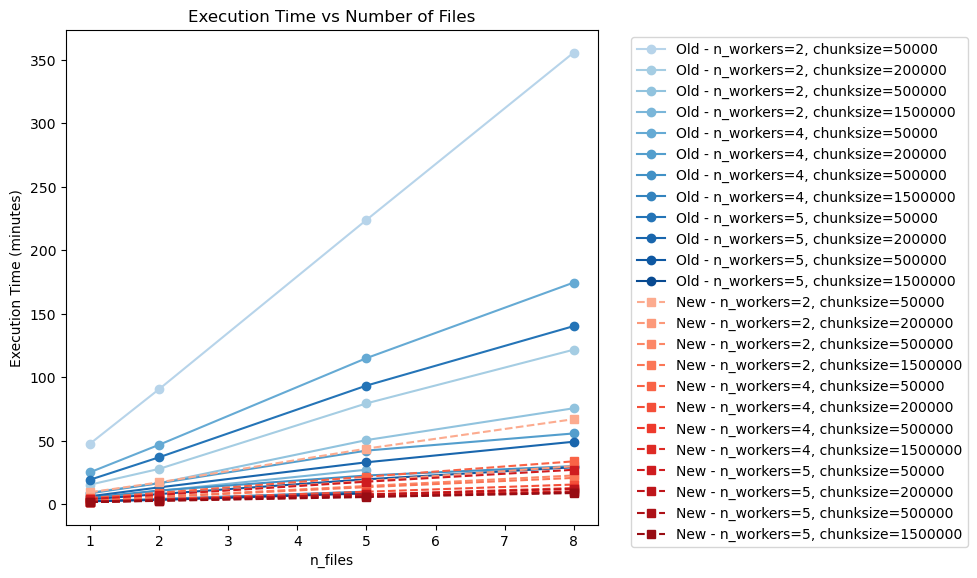

/tmp/ipykernel_27213/2061856289.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_27213/2061856289.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


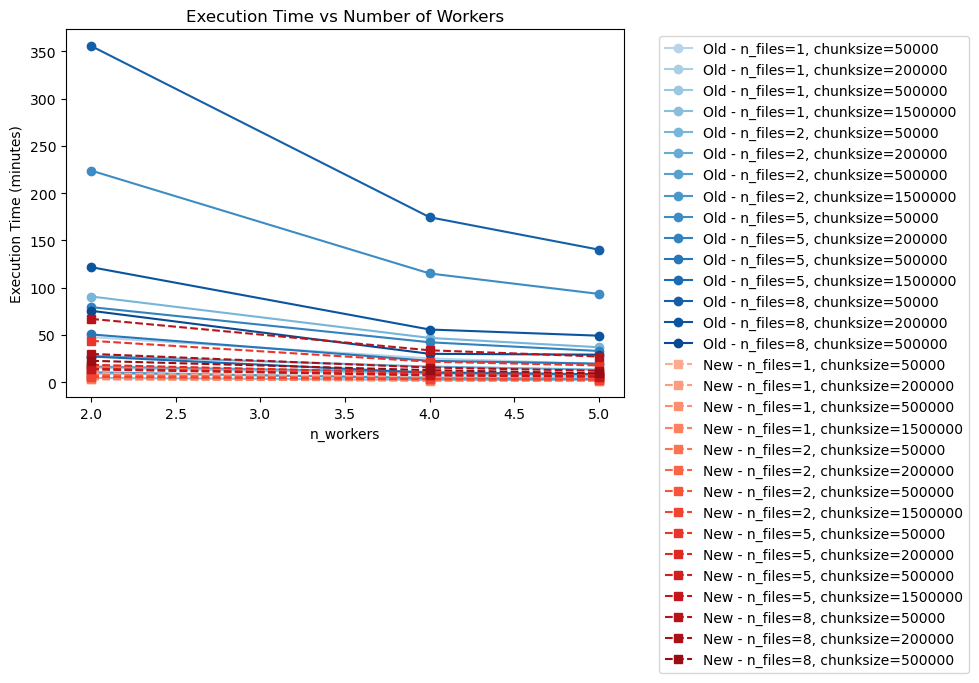

/tmp/ipykernel_27213/2061856289.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_27213/2061856289.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


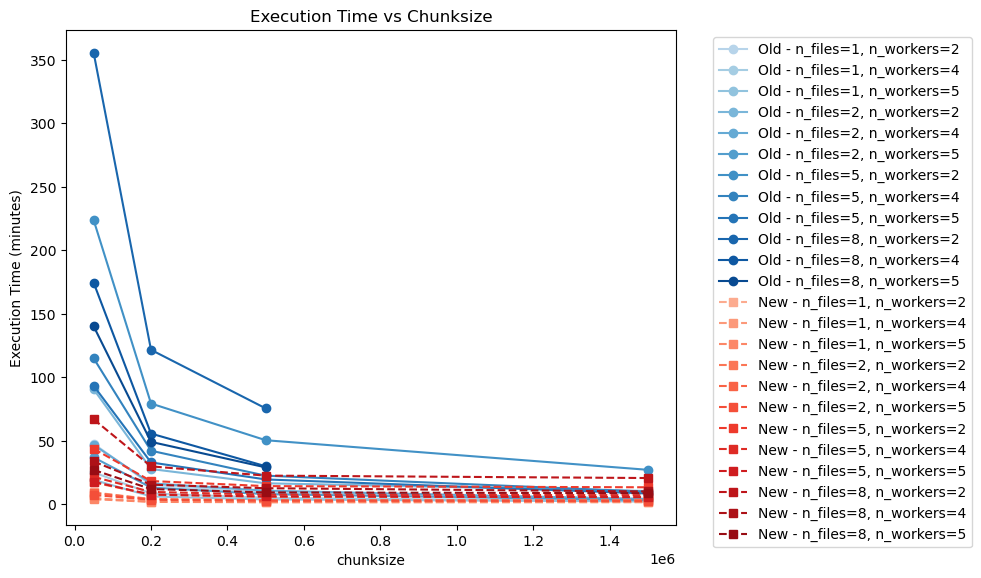

In [4]:
plot_execution_time(old_df, new_df, 'n_files', 'Execution Time vs Number of Files')
plot_execution_time(old_df, new_df, 'n_workers', 'Execution Time vs Number of Workers')
plot_execution_time(old_df, new_df, 'chunksize', 'Execution Time vs Chunksize')

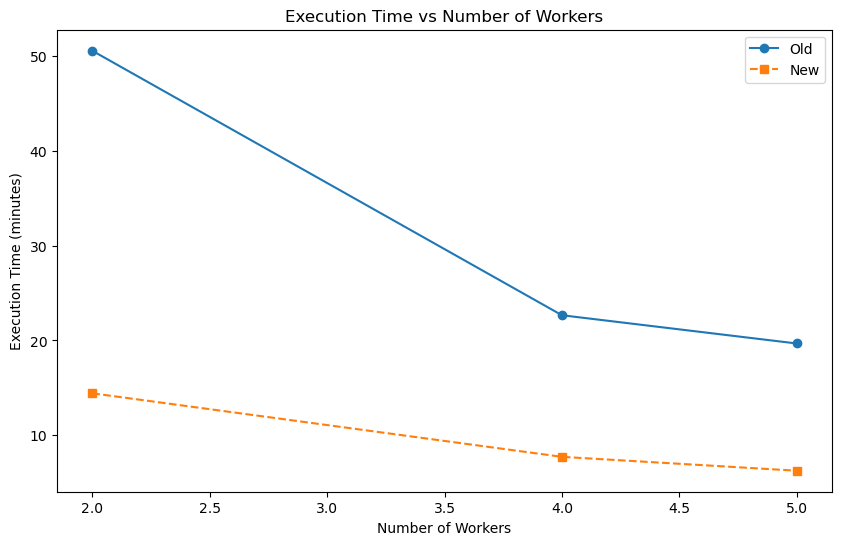

In [5]:
# in both cases, keep only the configurations with 5 files and chunksize 500000
old_df_l = old_df[(old_df['n_files'] == 5) & (old_df['chunksize'] == 500000)]
new_df_l = new_df[(new_df['n_files'] == 5) & (new_df['chunksize'] == 500000)]

# plot the execution time vs number of workers
plt.figure(figsize=(10, 6))
plt.plot(old_df_l['n_workers'], old_df_l['execution_time'], label='Old', linestyle='-', marker='o')
plt.plot(new_df_l['n_workers'], new_df_l['execution_time'], label='New', linestyle='--', marker='s')
plt.xlabel('Number of Workers')
plt.ylabel('Execution Time (minutes)')
plt.title('Execution Time vs Number of Workers')
plt.legend()
plt.show()

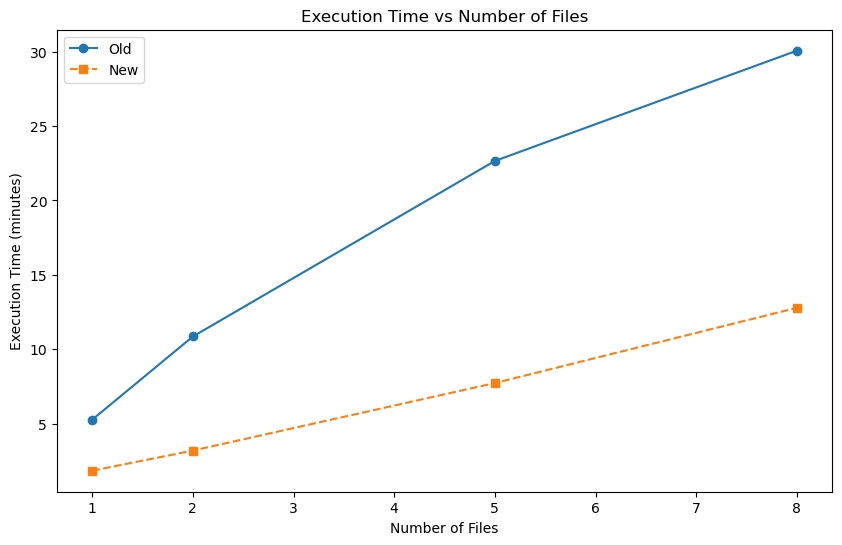

In [6]:
old_df_l = old_df[(old_df['chunksize'] == 500000) & (old_df['n_workers'] == 4)]
new_df_l = new_df[(new_df['chunksize'] == 500000) & (new_df['n_workers'] == 4)]

# plot the execution time vs number of workers
plt.figure(figsize=(10, 6))
plt.plot(old_df_l['n_files'], old_df_l['execution_time'], label='Old', linestyle='-', marker='o')
plt.plot(new_df_l['n_files'], new_df_l['execution_time'], label='New', linestyle='--', marker='s')
plt.xlabel('Number of Files')
plt.ylabel('Execution Time (minutes)')
plt.title('Execution Time vs Number of Files')
plt.legend()
plt.show()

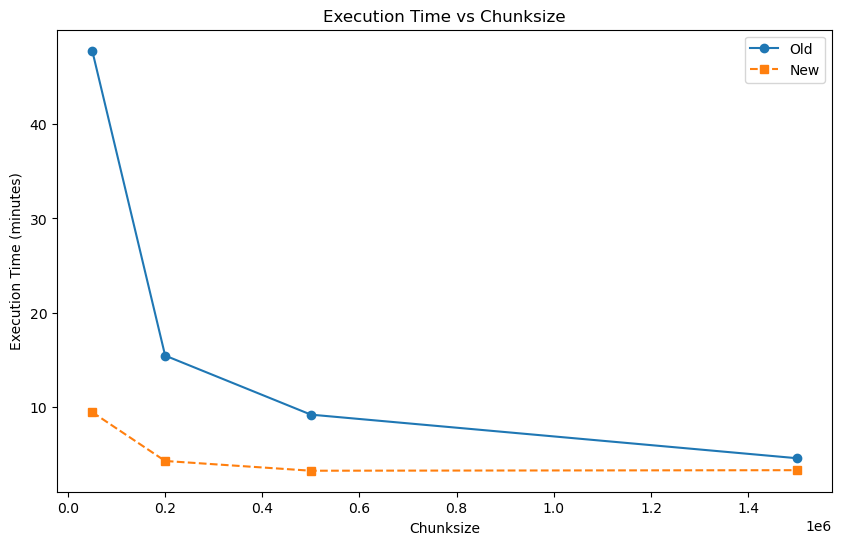

In [7]:
old_df_l = old_df[(old_df['n_files'] == 1) & (old_df['n_workers'] == 2)]
new_df_l = new_df[(new_df['n_files'] == 1) & (new_df['n_workers'] == 2)]

# plot the execution time vs number of workers
plt.figure(figsize=(10, 6))
plt.plot(old_df_l['chunksize'], old_df_l['execution_time'], label='Old', linestyle='-', marker='o')
plt.plot(new_df_l['chunksize'], new_df_l['execution_time'], label='New', linestyle='--', marker='s')
plt.xlabel('Chunksize')
plt.ylabel('Execution Time (minutes)')
plt.title('Execution Time vs Chunksize')
plt.legend()
plt.show()